Simulator: Start Here
=====================

This script is the starting point for simulating IC50 dose-response datasets
representative of the real GDSC2 (Genomics of Drug Sensitivity in Cancer, v2)
cancer cell-line drug screens used by the group, and provides an overview of
the IC50 simulation API used throughout `ic50_workspace`.

After reading this script, the rest of `scripts/` will provide examples for
fitting these simulated datasets and the real GDSC2 data with various
inference frameworks (one-by-one, EP, graphical, hierarchical).

__Contents__

- **Model:** The Hill dose-response model that turns latent gene-expression
  vectors into observed cell-viability intensities.
- **Plotters:** Overview of the shared plotting tool used for visualisation.
- **Dataset Paths:** The output folder layout the rest of the workspace expects.
- **Real Data Preview:** Show one example real GDSC2 curve to anchor what the
  simulator is trying to reproduce.
- **Configuration:** Numerical sizes and noise levels of the simulated sample.
- **Ground-Truth Global Linear Model:** The mapping from latent vectors to Hill
  parameters, used as ground truth.
- **Concentration Grid:** The log-concentration rank axis matching real GDSC2
  preprocessing.
- **Per-Dataset Simulation:** Generate the per-cell-line Hill curves, add noise,
  write data + visualisation.
- **Sample-Level Outputs:** Save the global ground-truth arrays alongside the
  per-dataset folders.
- **Console Summary:** Print a table of every simulated cell line's parameters
  and log-likelihood.

__Model__

This script simulates dose-response data for a `galaxy-scale` (here:
single-drug, single-tissue) study where:

 - Each simulated cell line has a 5-dimensional latent vector standing in for
   SVD-compressed gene-expression features.
 - A linear map (`coef_matrix_true`, `coef_mean_true`) takes that latent
   vector to the cell line's three Hill parameters
   `(log_ic50, n_log, base)`.
 - The Hill curve `y = base / (1 + exp(n*(x - log_ic50)))` produces the
   noiseless intensity at each log-concentration rank.
 - Gaussian noise of std-dev `NOISE_SIGMA` is added per point to mimic
   single-replicate GDSC2 plate-reader noise.

Sign convention: this simulator and `util.hill_curve` use the canonical
**decreasing** dose-response convention (high viability at low dose, low
viability at high dose), matching the legacy plotting style at
`concr/cancer_legacy/real/viz_hill.py`. Concr's production fitting code uses
the inverted convention; results crossing that boundary need a sign audit.

__Plotters__

All plotting is delegated to `util.plot_dataset` so simulated and real data
are rendered identically. See `scripts/util.py` for the full API.

In [1]:

import json
import sys
from pathlib import Path

import numpy as np

Make `util.py` importable whether this is being run as a script or executed
as a Jupyter notebook. As a script, `__file__` resolves to `scripts/`. As
a notebook generated by PyAutoBuild, `util.py` is copied next to the
notebook in `notebooks/` and the kernel's working directory is the
notebook's folder, so `Path.cwd()` gives the right location.

In [2]:
try:
    here = Path(__file__).resolve().parent
except NameError:  # running inside Jupyter where __file__ is undefined
    here = Path.cwd()
sys.path.insert(0, str(here))

from util import hill_curve, log_likelihood, plot_dataset

__Dataset Paths__

The `dataset_name` describes the simulated sample and gives it a descriptive
name. It defines the folder the dataset is output to on disk:

 - Per-dataset arrays go to `dataset/ic50_sim/dataset_<i>/`
   (`x.npy`, `y.npy`, `latent.npy`, plus `info.json` and `true_params.json`).
 - Ground-truth global arrays go to `dataset/ic50_sim/_sample/`
   (the linear map, latent matrix, hill-parameter matrix, and a JSON summary).

In [3]:
dataset_name = "ic50_sim"

workspace_root = here.parent
dataset_path = workspace_root / "dataset" / dataset_name
sample_meta_path = dataset_path / "_sample"
dataset_path.mkdir(parents=True, exist_ok=True)
sample_meta_path.mkdir(parents=True, exist_ok=True)

__Real Data Preview__

Before producing any simulated data, we load and plot one example real
GDSC2 cell line so the reader knows exactly what shape, amplitude, and
noise level the simulator is targeting. The dataset chosen here
(`cancer_real__drug_1073/dataset_20`) is a representative drug-1073 cell
line with a clear dose-response decline (intensity drops from ~63 000
counts at low dose to ~34 000 at high dose).

Real datasets do not come with ground-truth Hill parameters, so we call
`util.plot_dataset` *without* a `true_params` overlay. The same function
is used here for real data and below for simulated data, guaranteeing
that the two are visually comparable.

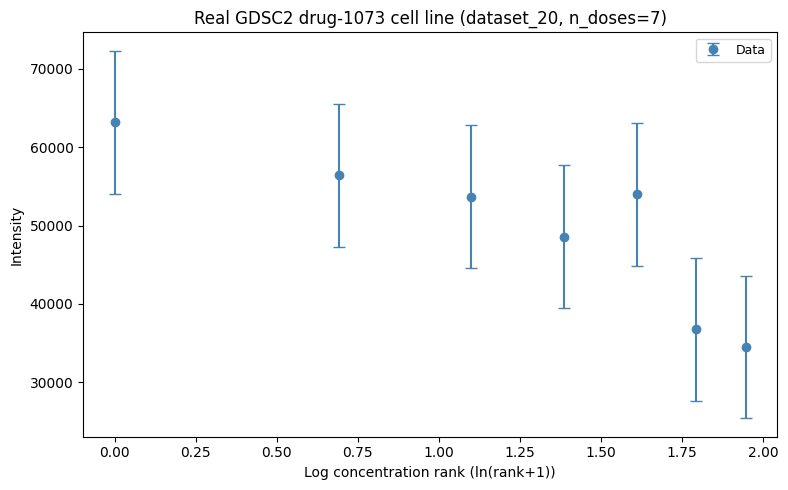

In [4]:
real_dataset_path = workspace_root / "dataset" / "cancer_real__drug_1073" / "dataset_20"
real_x = np.load(real_dataset_path / "x.npy")
real_y = np.load(real_dataset_path / "y.npy")
real_info = json.load(open(real_dataset_path / "info.json"))

plot_dataset(
    real_x,
    real_y,
    real_info["noise_sigma"],
    title=f"Real GDSC2 drug-1073 cell line (dataset_20, n_doses={real_info['n_doses']})",
    output_path=workspace_root / "dataset" / "ic50_sim" / "real_data_preview.png",
)

__Configuration__

Numerical sizes and noise levels of the simulated sample.

 - `N_DATASETS` : how many synthetic cell lines to generate.
 - `N_LATENT`   : dimensionality of the latent gene-expression vector. The
   real GDSC2 preprocessor in concr uses `N_LATENT = 20` (SVD components);
   we keep this small here for fast bootstrap run times — bump it later
   when fitting the real data alongside.
 - `N_DOSES`    : number of concentration points per curve. The median for
   real drug-1073 data is 7, so we match it.
 - `NOISE_SIGMA`: per-point Gaussian noise std-dev on the intensity scale.
   The hard-coded value 9099 mirrors concr; it is a plate-and-instrument
   specific noise level and is not derivable from any GDSC2 publication —
   keeping it here for compatibility with the existing real-data pipeline.
 - `RANDOM_SEED`: deterministic seed so the 5-dataset sample is reproducible.

In [5]:
N_DATASETS = 5
N_LATENT = 5
N_DOSES = 7
NOISE_SIGMA = 9099.0
RANDOM_SEED = 42

__Ground-Truth Global Linear Model__

Each cell line's Hill parameters are produced as

    hill_params[i] = latent_array[i] @ coef_matrix_true + COEF_MEAN_TRUE

The population-mean Hill parameters `COEF_MEAN_TRUE` are calibrated to put
the curves in the same regime as real drug-1073 data:

 - `log_ic50 = 1.0` sits comfortably inside the real x range
   `[0, ln(7) ~ 1.95]`, so each simulated curve shows visible decline.
 - `n_log   = 0.0` gives a Hill coefficient of `n = exp(0) = 1`, a moderate
   slope similar to typical real curves.
 - `base    = 35000` matches the median real `y_max` (~37k INTENSITY counts).

`coef_matrix_true` is drawn from a unit normal and rescaled column-wise so
that the per-cell-line variation in each Hill parameter is sensible:
log_ic50 std ~0.3, n_log std ~0.1, base std ~3000.

In [6]:
COEF_MEAN_TRUE = np.array([1.0, 0.0, 35000.0])

rng = np.random.default_rng(RANDOM_SEED)

coef_matrix_true = rng.normal(0.0, 1.0, size=(N_LATENT, 3))
col_scales = np.array(
    [
        0.3 / np.std(coef_matrix_true[:, 0]),
        0.1 / np.std(coef_matrix_true[:, 1]),
        3000.0 / np.std(coef_matrix_true[:, 2]),
    ]
)
coef_matrix_true = coef_matrix_true * col_scales

Synthetic latent vectors stand in for SVD-compressed RNAseq features. In
the real preprocessor each row is the cell line's 20-dim SVD latent; here
we draw `N_LATENT`-dim standard-normal vectors which is sufficient for
validating the simulation API.

In [7]:
latent_array = rng.normal(0.0, 1.0, size=(N_DATASETS, N_LATENT))

True Hill parameters per cell line, shape `(N_DATASETS, 3)` with columns
`[log_ic50, n_log, base]`.

In [8]:
hill_params_true = latent_array @ coef_matrix_true + COEF_MEAN_TRUE

__Concentration Grid__

The real GDSC2 preprocessor in concr defines the per-dataset x-axis as

    x = np.log(np.arange(n_doses) + 1)

(see `concr/simulators/preprocess_cancer_real.py`). This is a synthetic
monotone log-rank axis: x[0] = 0, x[1] = ln(2), x[2] = ln(3), ..., capped
at `ln(N_DOSES)`. We use the same formula here so simulated and real
datasets share an x-axis convention. Range with `N_DOSES = 7`:
`[0.0, ln(7) ~ 1.946]`.

Note: this differs from the canonical GDSC2 fitting convention
`x = log2(CONC/maxc) + 9` of Vis et al. 2016. concr's IC50 estimates are
therefore in this rank-log space and not directly interpretable as µM.

In [9]:
X_TEMPLATE = np.log(np.arange(N_DOSES) + 1)

__Per-Dataset Simulation__

For every cell line we evaluate the true Hill curve on `X_TEMPLATE`, add
Gaussian noise, then write the data files plus a diagnostic PNG via the
shared `util.plot_dataset` so the look matches what we will use for real
data later.

`info.json` follows the schema used elsewhere in concr so the same loader
can read both real and simulated folders unchanged. `true_params.json`
records the ground-truth Hill parameters and the log-likelihood of those
parameters against the noisy data, useful for post-fit validation.

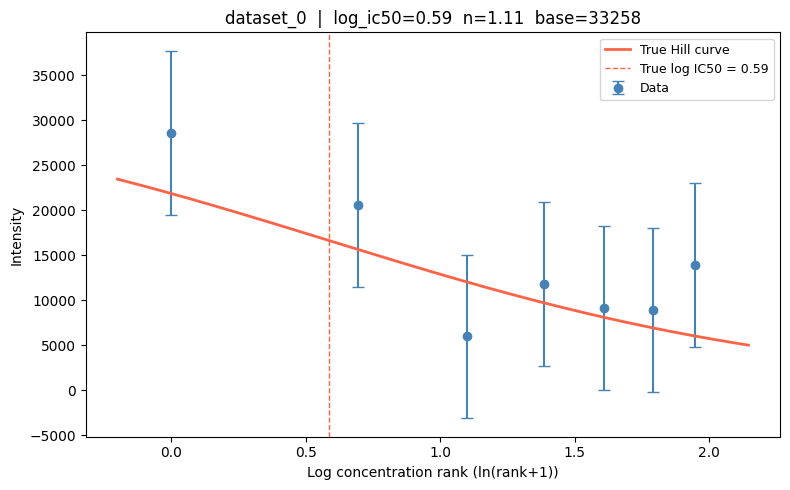

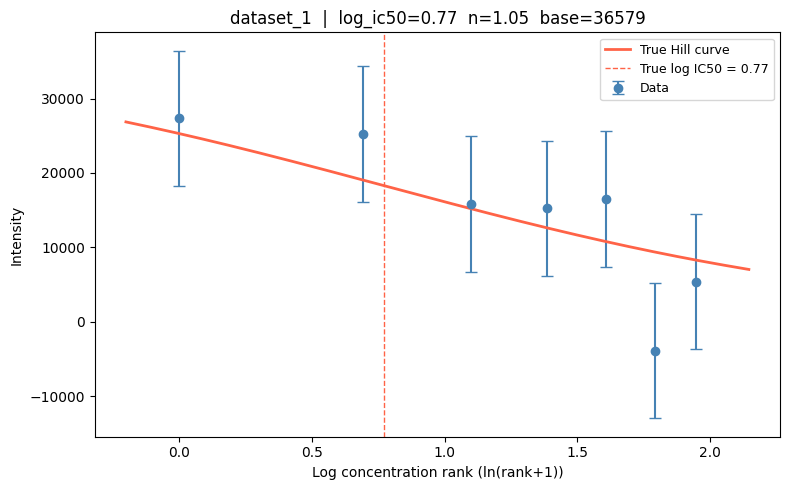

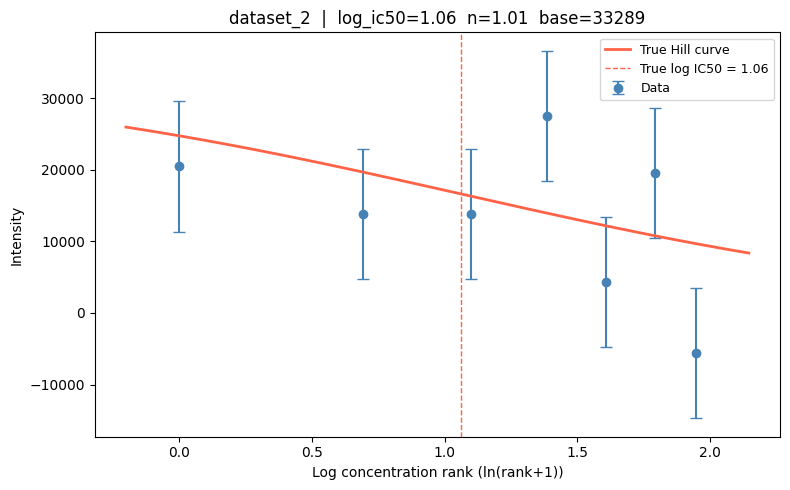

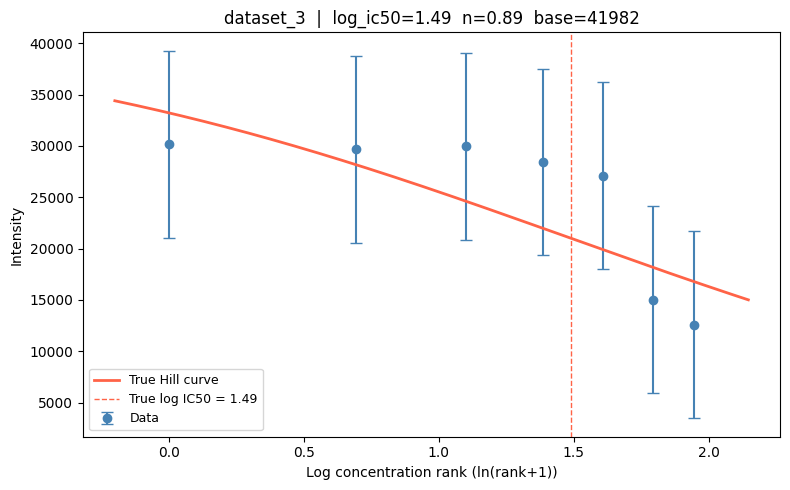

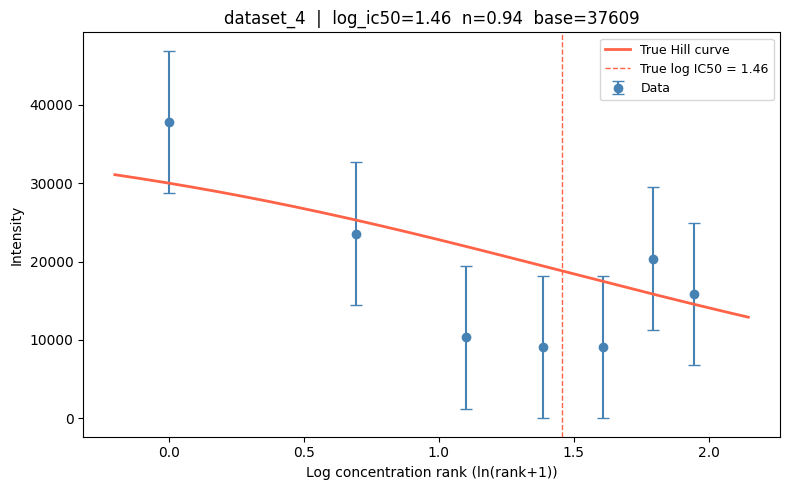

In [10]:
for i in range(N_DATASETS):
    log_ic50, n_log, base = hill_params_true[i]

    x = X_TEMPLATE.copy()
    y_true = hill_curve(x, log_ic50, n_log, base)
    noise = rng.normal(0.0, NOISE_SIGMA, size=N_DOSES)
    y = y_true + noise

    log_likelihood_true = log_likelihood(
        x, y, NOISE_SIGMA, log_ic50, n_log, base
    )

    cell_dir = dataset_path / f"dataset_{i}"
    cell_dir.mkdir(parents=True, exist_ok=True)

    np.save(cell_dir / "x.npy", x)
    np.save(cell_dir / "y.npy", y)
    np.save(cell_dir / "latent.npy", latent_array[i])

    true_params = {
        "log_ic50": float(log_ic50),
        "n_log": float(n_log),
        "n_hill_coef": float(np.exp(n_log)),
        "base": float(base),
        "log_likelihood_true": log_likelihood_true,
        "noise_sigma": NOISE_SIGMA,
    }
    with open(cell_dir / "true_params.json", "w") as f:
        json.dump(true_params, f, indent=4)

    info = {
        "domain": "cancer",
        "noise_sigma": NOISE_SIGMA,
        "n_latent": N_LATENT,
        "n_doses": N_DOSES,
        "simulated": True,
    }
    with open(cell_dir / "info.json", "w") as f:
        json.dump(info, f, indent=4)

    plot_dataset(
        x,
        y,
        NOISE_SIGMA,
        title=(
            f"dataset_{i}  |  log_ic50={log_ic50:.2f}  "
            f"n={np.exp(n_log):.2f}  base={base:.0f}"
        ),
        true_params={"log_ic50": log_ic50, "n_log": n_log, "base": base},
        output_path=cell_dir / "hill_curve.png",
    )

__Sample-Level Outputs__

Save the global ground-truth arrays in `_sample/` alongside the per-dataset
folders. These are what later sample-wide fits (EP, graphical, hierarchical)
will compare their inferred linear-model parameters against.

In [11]:
np.save(sample_meta_path / "coef_matrix_true.npy", coef_matrix_true)
np.save(sample_meta_path / "coef_mean_true.npy", COEF_MEAN_TRUE)
np.save(sample_meta_path / "hill_params_true.npy", hill_params_true)
np.save(sample_meta_path / "latent_array.npy", latent_array)

ground_truth = {
    "n_datasets": N_DATASETS,
    "n_latent": N_LATENT,
    "n_doses": N_DOSES,
    "noise_sigma": NOISE_SIGMA,
    "coef_mean_true": COEF_MEAN_TRUE.tolist(),
    "coef_matrix_true": coef_matrix_true.tolist(),
    "hill_params_true": hill_params_true.tolist(),
}
with open(sample_meta_path / "ground_truth.json", "w") as f:
    json.dump(ground_truth, f, indent=4)

__Console Summary__

Print a per-cell-line table to make it easy to eyeball the spread of
parameters and the log-likelihood of the truth against the noisy data.

In [12]:
print(f"Simulated {N_DATASETS} cell-line datasets -> {dataset_path}/")
print(f"\nTrue coef_mean [log_ic50, n_log, base] : {COEF_MEAN_TRUE}")
print("\nTrue Hill parameters and log-likelihoods per cell line:")
print(f"  {'dataset':<12} {'log_ic50':>10} {'n':>10} {'base':>10} {'log_L_true':>14}")
print(f"  {'-' * 60}")
for i in range(N_DATASETS):
    p = hill_params_true[i]
    x = X_TEMPLATE.copy()
    y = np.load(dataset_path / f"dataset_{i}" / "y.npy")
    log_l = log_likelihood(x, y, NOISE_SIGMA, p[0], p[1], p[2])
    print(
        f"  dataset_{i:<4}  {p[0]:>10.3f} {np.exp(p[1]):>10.3f} {p[2]:>10.1f} {log_l:>14.2f}"
    )


Simulated 5 cell-line datasets -> /home/jammy/Code/PyAutoLabs/z_projects/ic50_workspace/dataset/ic50_sim/

True coef_mean [log_ic50, n_log, base] : [1.0e+00 0.0e+00 3.5e+04]

True Hill parameters and log-likelihoods per cell line:
  dataset        log_ic50          n       base     log_L_true
  ------------------------------------------------------------
  dataset_0          0.588      1.109    33258.4          -1.08
  dataset_1          0.772      1.046    36578.6          -1.61
  dataset_2          1.061      1.005    33289.0          -3.73
  dataset_3          1.490      0.894    41982.0          -0.98
  dataset_4          1.456      0.943    37608.9          -2.40
